# Grammar Scoring Engine for Spoken English

**Task:** given a 45–60 s `.wav` recording, predict a continuous grammar score (MOS Likert, 0–5).
**Data:** 769 labelled training clips, 216 unlabelled test clips.
**Metrics:** RMSE (primary) and Pearson correlation, plus MAE / Spearman for context.

### Pipeline

```
          ┌────────────────────────── audio (.wav) ──────────────────────────┐
          │                                                                   │
   1. Preprocess (mono · 16 kHz · peak-normalise · keep pauses)               │
          │                                                                   │
   2. ASR: Whisper large-v3-turbo  ──►  raw transcript                        │
          │                                                                   │
   3. Transcript cleaning (fillers / ASR loops removed, grammar NOT corrected) │
          │                                                                   │
   4. Representations (all encoders frozen) ───────────────────────────┐     │
      a. Hand-crafted linguistic features (spaCy syntax, agreement     │     │
         checks, tense/clause use, lexical diversity, GPT-2 surprisal) │     │
      b. Text embeddings: RoBERTa + Qwen2.5-1.5B/3B, layers by CV      │     │
      c. Fluency / prosody features                          ◄─────────┼─────┤
      d. Speech embeddings: WavLM-base, WavLM-large, Whisper encoder ◄─┼─────┘
          │                                                            │
   5. Base regressors per block (Ridge / SVR / LightGBM) + a joint multi-block
      kernel SVR over all encoders; 5-fold × 3 repeats CV
          │
   6. Stacked ensemble (non-negative linear blend of out-of-fold predictions)
          │
   7. Clip to [0, 5]  ──►  grammar score
```

### Data policy: learning only from the provided training set
* The **only supervision** in this notebook is the training labels. Every regressor, the ensemble weights,
  and every modelling choice are fitted and selected on the training set with cross-validation.
* **No external grammar-scored or grammar-labelled data** is used, and nothing is fine-tuned on outside labels.
* Pretrained networks are used **frozen, as feature extractors only**:
  Whisper (speech → text, needed because no transcripts are provided; its encoder states are also used as
  speech features), and the self-supervised models GPT-2, RoBERTa-base, Qwen2.5-1.5B and -3B (base), WavLM-base
  and WavLM-large, which were pre-trained on raw unlabelled text/audio and never saw grammar labels.
* The test set is used only to produce the final predictions.

The **report** (approach, preprocessing, architecture, results) is in the final section;
all numbers quoted there are produced by the cells above it.

## 0. Setup

In [1]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

ROOT  = os.path.abspath(".")
DATA  = os.path.join(ROOT, "kaggle-dataset", "Dataset_Final")
CACHE = os.path.join(ROOT, "cache"); os.makedirs(CACHE, exist_ok=True)
SR = 16_000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

C:\Users\vsuma\Downloads\Kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1. Data overview

`train.csv` holds file names + labels; `test.csv` holds file names with placeholder labels (−1).

In [2]:
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test  = pd.read_csv(os.path.join(DATA, "test.csv"))
train["split"], test["split"] = "train", "test"
print(train.shape, test.shape)
print(train.label.describe().round(3).to_dict())
train.label.value_counts().sort_index().to_frame("count").T

(769, 3) (216, 3)
{'count': 769.0, 'mean': 3.313, 'std': 1.239, 'min': 0.0, '25%': 2.5, '50%': 3.0, '75%': 4.0, 'max': 5.0}


label,0.0,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
count,37,1,3,102,79,174,64,124,52,133


      duration                                         
         count  mean  std   min   25%   50%   75%   max
split                                                  
test     216.0  48.8  8.2   6.5  45.1  45.1  60.0  61.0
train    769.0  55.8  7.9  20.1  54.2  60.1  60.1  61.0
sample rates: {16000.0: 985} | channels: {1.0: 985}


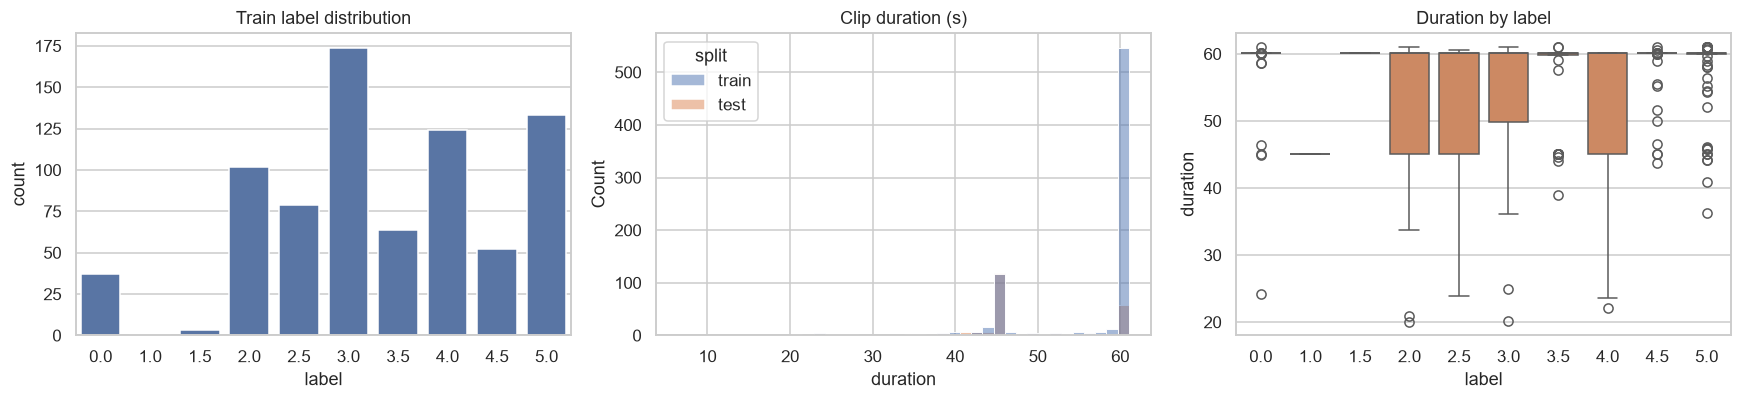

In [3]:
# Audio durations (header read only — fast)
import soundfile as sf
def info(split, f):
    i = sf.info(os.path.join(DATA, split, f))
    return i.duration, i.samplerate, i.channels
meta = pd.concat([train, test], ignore_index=True)
meta[["duration", "orig_sr", "channels"]] = [info(s, f) for s, f in zip(meta.split, meta.filename)]
print(meta.groupby("split")[["duration"]].describe().round(1))
print("sample rates:", meta.orig_sr.value_counts().to_dict(), "| channels:", meta.channels.value_counts().to_dict())

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
sns.countplot(x=train.label, ax=ax[0], color="#4C72B0"); ax[0].set_title("Train label distribution")
sns.histplot(data=meta, x="duration", hue="split", bins=40, ax=ax[1]); ax[1].set_title("Clip duration (s)")
sns.boxplot(data=meta[meta.split == "train"], x="label", y="duration", ax=ax[2], color="#DD8452")
ax[2].set_title("Duration by label"); plt.tight_layout(); plt.show()

In [4]:
# Where do the label-0 clips come from? File IDs reveal a separate recording batch.
meta["file_id"] = meta.filename.str.extract(r"(\d+)")[0].astype(int)
meta["id_range"] = pd.cut(meta.file_id, [-1, 500, 1000, 5000, 10_000], labels=["0–500", "501–1000", "1001–5000", "5001+"])
tab = meta.groupby(["split", "id_range"], observed=True).agg(clips=("label", "size"), mean_label=("label", "mean"),
                                                            label_0=("label", lambda s: (s == 0).sum()))
tab

clips  mean_label  label_0
split id_range                            
test  0–500       216   -1.000000        0
train 0–500       474    3.415612        0
      501–1000    258    3.600775        0
      5001+        37    0.000000       37

**Observations.**
* Labels are on a half-point grid. Rubric-scored clips (1–5) average about 3.5.
* **37 clips are labelled 0**, a value the 1–5 rubric does not define. All of them, and only them, come from a
  separate batch (file IDs 5037–5073). **No test clip comes from that batch**: every test file ID is ≤ 500.
* Section 4 shows their transcripts contain ordinary, scoreable speech. So 0 looks like a placeholder or
  "not rated" marker rather than a judgement of grammar.

**Decision:** these 37 clips are **excluded from model training and model selection**. Fitting them would teach
the model that ordinary speech can score 0. That pulls every prediction down and inflates RMSE on the 1–5
population the test set comes from. Section 7 includes an ablation that measures this effect. File IDs are only
used for this diagnosis and are **never** given to the model as a feature.

## 2. Audio preprocessing

* decode → **mono**, resample to **16 kHz** (the rate Whisper and WavLM expect)
* **peak-normalise** to 0.95 so loud and quiet recordings look alike to downstream models
* **no internal silence removal**: pauses are kept for ASR, and pause statistics are measured as fluency features

From an adaptive energy voice-activity detector (frames ≥ 12 dB, or half the dynamic range for noisy clips, above the clip's own noise floor) we derive fluency/prosody
features: speech ratio, number and length of pauses, energy variation, and pitch statistics.

In [5]:
def load_audio(path):
    # Mono, 16 kHz, peak-normalised float32. Internal pauses are preserved.
    y, _ = librosa.load(path, sr=SR, mono=True)
    peak = np.abs(y).max()
    return (y / peak * 0.95).astype(np.float32) if peak > 0 else y

HOP = 256

def speech_segments(y, margin_db=12):
    # Adaptive energy VAD: a frame is speech if it is above the clip's own noise floor (10th percentile of
    # frame energy) by `margin_db`, or by half the clip's dynamic range for noisy, low-contrast recordings.
    db = librosa.amplitude_to_db(librosa.feature.rms(y=y, frame_length=1024, hop_length=HOP)[0], ref=np.max)
    floor, top = np.percentile(db, [10, 95])
    sp = db > floor + min(margin_db, 0.5 * (top - floor))
    edges = np.flatnonzero(np.diff(np.r_[0, sp.astype(int), 0]))
    iv = edges.reshape(-1, 2) * HOP
    return iv[(iv[:, 1] - iv[:, 0]) > 0.05 * SR], db       # drop blips shorter than 50 ms

def acoustic_features(y):
    # Fluency / prosody descriptors from the adaptive VAD.
    dur = len(y) / SR
    iv, db = speech_segments(y)
    speech = (iv[:, 1] - iv[:, 0]).sum() / SR if len(iv) else 0.0
    gaps = (iv[1:, 0] - iv[:-1, 1]) / SR if len(iv) > 1 else np.array([])
    pauses = gaps[gaps > 0.3]
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=HOP)[0]
    f0 = librosa.yin(y, fmin=70, fmax=400, sr=SR, frame_length=1024, hop_length=512)
    voiced = f0[(f0 > 75) & (f0 < 390)]
    return {
        "duration": dur,
        "speech_time": speech,
        "speech_ratio": speech / dur if dur else 0,
        "n_pauses": len(pauses),
        "pauses_per_min": len(pauses) / dur * 60 if dur else 0,
        "mean_pause": pauses.mean() if len(pauses) else 0,
        "long_pause_ratio": (gaps > 1.0).sum() / max(len(gaps), 1),
        "rms_mean": rms.mean(), "rms_cv": rms.std() / (rms.mean() + 1e-8),
        "dynamic_range_db": np.percentile(db, 95) - np.percentile(db, 10),
        "f0_median": np.median(voiced) if len(voiced) else 0,
        "f0_iqr": np.subtract(*np.percentile(voiced, [75, 25])) if len(voiced) else 0,
    }

path = os.path.join(CACHE, "acoustic.csv")
if os.path.exists(path):
    acoustic = pd.read_csv(path)
else:
    rows = [acoustic_features(load_audio(os.path.join(DATA, s, f))) for s, f in tqdm(zip(meta.split, meta.filename), total=len(meta))]
    acoustic = pd.concat([meta[["split", "filename"]], pd.DataFrame(rows)], axis=1)
    acoustic.to_csv(path, index=False)
acoustic.head()

,split,filename,duration,speech_time,speech_ratio,n_pauses,pauses_per_min,mean_pause,long_pause_ratio,rms_mean,rms_cv,dynamic_range_db,f0_median,f0_iqr
0,train,audio_192.wav,60.508375,38.272,0.632507,20,19.831965,0.830400,0.125000,0.059623,1.328108,53.983227,163.737868,54.821312
1,train,audio_436.wav,60.074688,45.488,0.757191,8,7.990054,0.572000,0.010526,0.065313,0.917747,30.486979,220.010975,55.961184
2,train,audio_447.wav,60.074688,44.336,0.738015,16,15.980108,0.647000,0.015385,0.051635,1.118256,41.577114,142.999017,45.146343
3,train,audio_126.wav,45.060000,34.096,0.756680,13,17.310253,0.525538,0.000000,0.037680,0.993798,36.993626,129.549071,151.186753
4,train,audio_61.wav,45.300000,37.648,0.831082,8,10.596026,0.600000,0.034483,0.047815,1.063562,64.172580,123.208041,51.679324


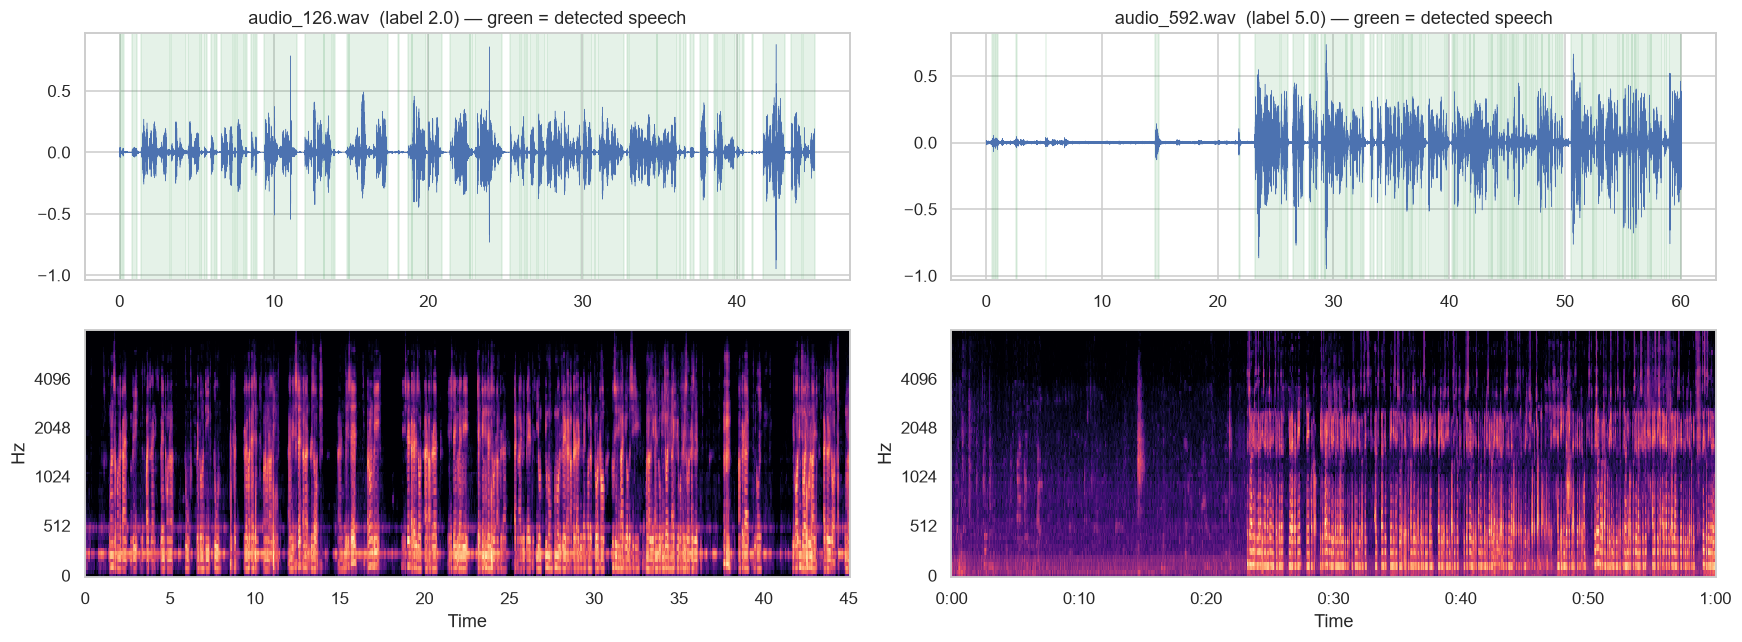

In [6]:
# Visual sanity check: a low-scored vs a high-scored clip (raw waveform, VAD segments, log-mel spectrogram)
ex = [train[train.label == 2.0].filename.iloc[0], train[train.label == 5.0].filename.iloc[0]]
fig, ax = plt.subplots(2, 2, figsize=(16, 6))
for j, f in enumerate(ex):
    y = load_audio(os.path.join(DATA, "train", f))
    t = np.arange(len(y)) / SR
    ax[0, j].plot(t, y, lw=0.3, color="#4C72B0")
    for s, e in speech_segments(y)[0]:
        ax[0, j].axvspan(s / SR, e / SR, color="#55A868", alpha=0.15)
    ax[0, j].set_title(f"{f}  (label {train.set_index('filename').label[f]}) — green = detected speech")
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_mels=80), ref=np.max)
    librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="mel", ax=ax[1, j])
plt.tight_layout(); plt.show()

## 3. Speech-to-text (Whisper large-v3-turbo)

The ASR model answers *"what words were said?"*; it does not judge grammar. We use
`openai/whisper-large-v3-turbo` in fp16 on the GPU, forced to English, with Whisper's native long-form
(sequential 30 s window) decoding and temperature fallback against repetition loops. Whisper tends to smooth disfluencies but leaves most grammatical errors in place
(*"he go to school yesterday"* stays as spoken), and those errors are what we measure.

Transcription is the slowest step (~3 s/clip on an RTX 3050), so results are cached to `cache/transcripts.csv`.

In [7]:
TRANSCRIPTS = os.path.join(CACHE, "transcripts.csv")

class Transcriber:
    # Whisper long-form decoding with temperature fallback: if a segment's output is too repetitive
    # (gzip compression ratio > 1.8) or low-confidence, it is re-decoded at a higher temperature.
    # This suppresses the "I'm sorry, I'm sorry, ..." loops that greedy chunked decoding produces on noisy clips.
    def __init__(self, name="openai/whisper-large-v3-turbo"):
        from transformers import WhisperForConditionalGeneration, WhisperProcessor
        self.proc = WhisperProcessor.from_pretrained(name)
        self.model = WhisperForConditionalGeneration.from_pretrained(name, dtype=torch.float16).to(DEVICE).eval()

    @torch.no_grad()
    def __call__(self, y):
        feats = self.proc(y, sampling_rate=SR, return_tensors="pt", truncation=False,
                          padding="longest", return_attention_mask=True)
        if feats.input_features.shape[-1] < 3000:          # < 30 s: pad to Whisper's fixed window
            feats = self.proc(y, sampling_rate=SR, return_tensors="pt", return_attention_mask=True)
        ids = self.model.generate(
            feats.input_features.to(DEVICE, torch.float16), attention_mask=feats.attention_mask.to(DEVICE),
            language="en", task="transcribe", return_timestamps=True, condition_on_prev_tokens=False,
            temperature=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
            compression_ratio_threshold=1.8, logprob_threshold=-1.0, no_speech_threshold=0.6)
        return self.proc.batch_decode(ids, skip_special_tokens=True)[0].strip()

def transcribe_all(items):
    asr = Transcriber()
    out = [{"split": s, "filename": f, "transcript": asr(load_audio(os.path.join(DATA, s, f)))} for s, f in tqdm(items)]
    del asr; torch.cuda.empty_cache()
    return pd.DataFrame(out)

cached = pd.read_csv(TRANSCRIPTS, keep_default_na=False) if os.path.exists(TRANSCRIPTS) else pd.DataFrame(columns=["split", "filename", "transcript"])
todo = [(s, f) for s, f in zip(meta.split, meta.filename) if (s, f) not in set(zip(cached.split, cached.filename))]
if todo:
    cached = pd.concat([cached, transcribe_all(todo)], ignore_index=True)
    cached.to_csv(TRANSCRIPTS, index=False)
df = meta.merge(cached, on=["split", "filename"]).merge(acoustic, on=["split", "filename", "duration"])
df["transcript"] = df.transcript.fillna("").astype(str)
print(df.shape, "| empty transcripts:", (df.transcript.str.len() == 0).sum())
for _, r in df[df.split == "train"].sample(4, random_state=1).iterrows():
    print(f"\n[{r.label}] {r.transcript[:400]}")

(985, 20) | empty transcripts: 0

[4.0] The most enchanting schools always have large open playgrounds with interesting play equipment that leaves many options for creativity. Children sit at their classroom desk for many hours each day. They are given perks between when they can go outside outdoors to the playground. The key to these playgrounds is choice. Use the play equipment, run on the field, jump rope, basketball or create some g

[4.0] My favorite hobby is always listening to music. Whenever I am sad, depressed or even happy and inclusive, I think my hands down job would be to take a headphone, take a phone, take my mobile and listen to music. Music helps you relax and if I am sad it definitely helps me to make my mind free from the things that made me sad and also gives a relaxation. I listen to different kinds of music. I don'

[0.0] So it was like a fun material. And it's basically an extra space. And then you can use your organic products. And products that basically use yo

## 4. Transcript cleaning

We only remove material that is **not linguistic content**:

* hesitation fillers (*um, uh, erm, hmm*). Their rate is kept as a feature first.
* Whisper "loop" hallucinations (the same phrase repeated ≥ 4 times back-to-back)
* whitespace / punctuation artefacts

We **never correct grammar**: *"she go to school yesterday"* stays as it is, because those errors are the signal.

In [8]:
FILLER_RE = re.compile(r"\b(?:u+[hm]+|e+rm*|a+h+|h+m+|m+h*m+|uh-huh)\b[,.]?", re.I)
LOOP_RE   = re.compile(r"\b(.{4,80}?)(?:[\s,.]+\1\b){3,}", re.I)

def clean_transcript(t):
    t = LOOP_RE.sub(r"\1", t)
    t = FILLER_RE.sub(" ", t)
    t = re.sub(r"\s+([,.!?])", r"\1", t)
    t = re.sub(r"([,.!?])[,.]+", r"\1", t)
    t = re.sub(r"\s+", " ", t).strip(" ,.")
    return t

df["n_fillers"] = df.transcript.str.count(FILLER_RE)
df["had_loop"]  = df.transcript.str.contains(LOOP_RE).astype(int)
df["text"] = df.transcript.map(clean_transcript)
df["n_words_raw"] = df.text.str.split().str.len().fillna(0)
print("clips with ASR loops:", df.had_loop.sum(), "| total fillers:", df.n_fillers.sum())

# What do the label-0 clips look like?
z = df[(df.split == "train") & (df.label == 0)]
print(f"\nlabel-0 clips: {len(z)} | median words {z.n_words_raw.median():.0f} vs {df[df.label > 0].n_words_raw.median():.0f} for the rest")
for _, r in z.head(6).iterrows():
    print(f" - {r.filename}: dur={r.duration:.0f}s words={r.n_words_raw:.0f} | {r.text[:160]!r}")
print("\nRecording dynamic range (dB, median):",
      df.groupby(np.where(df.label == 0, "label-0 batch", np.where(df.split == "test", "test", "train 1–5"))).dynamic_range_db.median().round(1).to_dict())

clips with ASR loops: 1 | total fillers: 169

label-0 clips: 37 | median words 106 vs 100 for the rest
 - audio_5055.wav: dur=60s words=50 | 'Well pedaling, the wind bursts on my stream. that I felt so much more daily. Every time I leave the microphone, I can make myself forget the truth so that it ev'
 - audio_5066.wav: dur=60s words=91 | "The best day in our life is the best day together and the better means that we live after 3 years. It's a wonderful day in my life because we all live at the sa"
 - audio_5069.wav: dur=60s words=19 | 'you the the the the the and the material cement is to learn about the products of the product'
 - audio_5073.wav: dur=60s words=138 | 'I am going to tell you about this theme of the product market. The product market is full of people are selling and buying these vegetables or etc. In the marke'
 - audio_5039.wav: dur=60s words=32 | 'so The playground is a library hub for activities where students have to plan to equip and unleash their creativity. the

## 5. Linguistic features

### 5a. Hand-crafted syntax / lexical features (spaCy `en_core_web_sm`)

| group | features |
|---|---|
| volume & rate | words, sentences, words per second of speech |
| sentence structure | mean / max sentence length, dependency-tree depth, subordinate clauses per sentence, fragment ratio (sentences with no verb) |
| grammar error heuristics | subject–verb agreement violations, *a/an* misuse, doubled words |
| morphology & tense | past / present / modal / progressive / perfect / passive rates |
| lexical | type-token ratio, Guiraud index, word length, long-word ratio |
| part-of-speech mix | rate of nouns, verbs, pronouns, determiners, adpositions, conjunctions … |

In [9]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner"])

SUBORD = {"advcl", "ccomp", "xcomp", "acl", "relcl", "csubj"}
SING_PRON, PLUR_PRON = {"he", "she", "it", "this", "that"}, {"i", "you", "we", "they"}
VOWEL_SOUND = re.compile(r"^(?:[aeio]|u(?!ni|se|su|ro|ti)|hour|honest|heir)", re.I)

def depth(tok):
    # Distance from token to its sentence root (spaCy roots are their own head; compare by index).
    d = 0
    while tok.head.i != tok.i: tok, d = tok.head, d + 1
    return d

def sv_agreement_errors(doc):
    # Present-tense verbs whose number disagrees with their nominal/pronominal subject.
    err = 0
    for t in doc:
        if t.dep_ != "nsubj": continue
        v = t.head
        # If an auxiliary carries the agreement, check it instead of the main verb
        aux = [c for c in v.children if c.dep_ in ("aux", "auxpass") and c.tag_ in ("VBZ", "VBP")]
        v = aux[0] if aux else v
        if v.tag_ not in ("VBZ", "VBP"): continue
        w = t.lower_
        sing = t.tag_ in ("NN", "NNP") or w in SING_PRON
        plur = t.tag_ in ("NNS", "NNPS") or w in PLUR_PRON
        if (sing and v.tag_ == "VBP" and w not in PLUR_PRON) or (plur and v.tag_ == "VBZ"):
            err += 1
    return err

def article_errors(doc):
    err = 0
    for a, nxt in zip(doc[:-1], doc[1:]):
        if a.lower_ == "a" and VOWEL_SOUND.match(nxt.text) and nxt.is_alpha: err += 1
        if a.lower_ == "an" and not VOWEL_SOUND.match(nxt.text) and nxt.is_alpha: err += 1
    return err

def text_features(doc, speech_time):
    words = [t for t in doc if t.is_alpha]
    n = len(words); sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    ns = max(len(sents), 1); nn = max(n, 1)
    slen = np.array([sum(t.is_alpha for t in s) for s in sents]) if sents else np.array([0])
    verbs = [t for t in doc if t.pos_ in ("VERB", "AUX")]
    nv = max(len(verbs), 1)
    lower = [t.lower_ for t in words]
    f = {
        "n_words": n, "n_sents": len(sents),
        "words_per_sec": n / speech_time,
        "sent_len_mean": slen.mean(), "sent_len_max": slen.max(), "sent_len_std": slen.std(),
        "tree_depth_mean": np.mean([max(depth(t) for t in s) for s in sents]) if sents else 0,
        "subord_per_sent": sum(t.dep_ in SUBORD for t in doc) / ns,
        "conj_per_sent": sum(t.dep_ == "conj" for t in doc) / ns,
        "mark_per_sent": sum(t.dep_ == "mark" for t in doc) / ns,
        "fragment_ratio": sum(not any(t.pos_ in ("VERB", "AUX") for t in s) for s in sents) / ns,
        "sv_err_rate": sv_agreement_errors(doc) / ns,
        "article_err_rate": article_errors(doc) / ns,
        "dup_word_rate": sum(a == b for a, b in zip(lower, lower[1:])) / nn,
        "ttr": len(set(lower)) / nn, "guiraud": len(set(lower)) / np.sqrt(nn),
        "word_len_mean": np.mean([len(w) for w in lower]) if n else 0,
        "long_word_ratio": sum(len(w) > 6 for w in lower) / nn,
        "past_rate": sum("Past" in t.morph.get("Tense") for t in verbs) / nv,
        "pres_rate": sum("Pres" in t.morph.get("Tense") for t in verbs) / nv,
        "modal_rate": sum(t.tag_ == "MD" for t in doc) / nv,
        "prog_rate": sum(t.tag_ == "VBG" for t in verbs) / nv,
        "perfect_rate": sum(t.tag_ == "VBN" and any(c.lemma_ == "have" for c in t.children) for t in verbs) / nv,
        "passive_rate": sum(t.dep_ in ("nsubjpass", "auxpass") for t in doc) / ns,
        "verbs_per_sent": len(verbs) / ns,
    }
    for pos in ("NOUN", "VERB", "PRON", "DET", "ADP", "ADJ", "ADV", "CCONJ", "SCONJ", "AUX", "PROPN", "INTJ"):
        f[f"pos_{pos.lower()}"] = sum(t.pos_ == pos for t in doc) / nn
    return f

docs = list(nlp.pipe(df.text, batch_size=64))
df["sents"] = [[s.text.strip() for s in d.sents if any(t.is_alpha for t in s)] for d in docs]
# speech time is floored at 30 % of the clip so a VAD miss on a noisy recording cannot explode the rate
hand = pd.DataFrame([text_features(d, max(st, 0.3 * du)) for d, st, du in zip(docs, df.speech_time, df.duration)])
hand.describe().T[["mean", "std", "min", "max"]].round(3).head(12)

,mean,std,min,max
n_words,99.280,26.243,8.000,174.000
n_sents,5.527,2.960,1.000,15.000
words_per_sec,2.869,0.991,1.006,10.079
sent_len_mean,25.851,22.251,4.357,145.000
sent_len_max,42.041,24.105,8.000,145.000
sent_len_std,10.225,8.607,0.000,61.000
tree_depth_mean,5.527,2.151,1.500,23.000
subord_per_sent,2.370,2.691,0.000,29.000
conj_per_sent,1.480,1.767,0.000,15.000
mark_per_sent,0.435,0.678,0.000,7.000


### 5b. Language-model surprisal (GPT-2)

**GPT-2 negative log-likelihood (NLL)** measures how "surprising" each sentence is to a language model
pre-trained on raw English text with no grammar labels. Ungrammatical word orders and agreement errors get
higher NLL. Per clip we keep the mean, max and std over sentences. GPT-2 is frozen, so it learns nothing from
our labels and only supplies features.

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

def cached_npy(name, fn):
    p = os.path.join(CACHE, name)
    if os.path.exists(p): return np.load(p, allow_pickle=True)
    arr = fn(); np.save(p, arr); return arr

@torch.no_grad()
def gpt2_nll():
    tok = AutoTokenizer.from_pretrained("openai-community/gpt2")
    mdl = AutoModelForCausalLM.from_pretrained("openai-community/gpt2").to(DEVICE).eval()
    out = np.zeros((len(df), 3))
    for i, ss in enumerate(tqdm(df.sents, desc="GPT-2")):
        per = []
        for s in ss:
            ids = tok(tok.bos_token + s, return_tensors="pt", truncation=True, max_length=256).input_ids.to(DEVICE)
            if ids.shape[1] < 3: continue
            per.append(mdl(ids, labels=ids).loss.item())
        out[i] = [np.mean(per), np.max(per), np.std(per)] if per else [np.nan] * 3
    del mdl; torch.cuda.empty_cache()
    return out

nll = cached_npy("gpt2_nll.npy", gpt2_nll)
hand[["gpt2_nll_mean", "gpt2_nll_max", "gpt2_nll_std"]] = nll

### 5c. Dense embeddings

All encoders are frozen. We keep **every layer's** time-averaged hidden state, because different depths encode
different things (acoustics → phonetics → words → syntax). Section 7a picks the best layers *by cross-validation
on the training set only*.

| block | model | pre-training (no grammar labels) | what it captures |
|---|---|---|---|
| text | `roberta-base` | masked-LM on raw text | word order, agreement, syntax of the transcript |
| text | `Qwen/Qwen2.5-1.5B` and `Qwen/Qwen2.5-3B` (**base** LMs, not instruction-tuned) | next-token prediction on raw text | a far larger language model's sense of whether the word sequence is well-formed English |
| audio | `microsoft/wavlm-base-plus` | self-supervised speech | pronunciation, rhythm, fluency |
| audio | `microsoft/wavlm-large` | self-supervised speech (larger) | same, higher capacity |
| audio + language | Whisper large-v3-turbo **encoder** | the ASR model we already run | acoustic *and* linguistic content in one representation, including hesitations the transcript drops |

In [11]:
@torch.no_grad()
def text_layers(model_name, texts, max_len=512):
    # Mean-pooled hidden state of every layer (embeddings + 12 transformer layers) for each transcript.
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
    out = []
    for t in tqdm(texts, desc=model_name):
        enc = tok(t or ".", truncation=True, max_length=max_len, return_tensors="pt").to(DEVICE)
        out.append(torch.stack([h[0].mean(0) for h in mdl(**enc, output_hidden_states=True).hidden_states]).float().cpu().numpy())
    del mdl; torch.cuda.empty_cache()
    return np.stack(out)

def windows(y, win_s):
    # Non-overlapping windows; a trailing scrap shorter than 1 s is dropped.
    return [y[a:a + win_s * SR] for a in range(0, len(y), win_s * SR) if a == 0 or len(y[a:a + win_s * SR]) >= SR]

@torch.no_grad()
def wavlm_layers(name, win_s=20, average_layers=False):
    from transformers import AutoFeatureExtractor
    fe = AutoFeatureExtractor.from_pretrained(name)
    mdl = AutoModel.from_pretrained(name, dtype=torch.float16).to(DEVICE).eval()
    out = []
    for s, f in tqdm(list(zip(df.split, df.filename)), desc=name):
        hs = []
        for c in windows(load_audio(os.path.join(DATA, s, f)), win_s):
            x = fe(c, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE).half()
            hs.append(torch.stack(mdl(x, output_hidden_states=True).hidden_states).squeeze(1).float().cpu())
        h = torch.cat(hs, 1).mean(1)                                       # layers x dim
        out.append((h[1:].mean(0) if average_layers else h).numpy())
    del mdl; torch.cuda.empty_cache()
    return np.stack(out)

WHISPER_LAYERS = list(range(4, 33, 4))                                  # encoder layers 4, 8, ..., 32
@torch.no_grad()
def whisper_encoder_layers(name="openai/whisper-large-v3-turbo"):
    from transformers import WhisperFeatureExtractor, WhisperModel
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name, dtype=torch.float16).encoder.to(DEVICE).eval()
    out = np.zeros((len(df), len(WHISPER_LAYERS), 2, 1280), np.float32)
    for i, (s, f) in enumerate(tqdm(list(zip(df.split, df.filename)), desc="Whisper encoder")):
        hs = []
        for c in windows(load_audio(os.path.join(DATA, s, f)), 30):
            x = fe(c, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE).half()
            n = max(1, int(len(c) / SR * 50))                              # 20 ms frames; ignore the zero-padding
            h = enc(x, output_hidden_states=True).hidden_states
            hs.append(torch.stack([h[l][0, :n] for l in WHISPER_LAYERS]).float().cpu())
        h = torch.cat(hs, 1)
        out[i, :, 0], out[i, :, 1] = h.mean(1).numpy(), h.std(1).numpy()
    del enc; torch.cuda.empty_cache()
    return out

@torch.no_grad()
def llm_layers(model_name, texts, max_tokens=1024):
    # Mean-pooled hidden state of every layer of a frozen base causal LM (fp16).
    from transformers import AutoModelForCausalLM
    tok = AutoTokenizer.from_pretrained(model_name)
    # device_map="auto" keeps as many layers on the 6 GB GPU as fit and spills the rest to CPU RAM
    mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float16, device_map="auto",
                                               max_memory={0: "5GiB", "cpu": "12GiB"}).eval()
    out = []
    for t in tqdm(texts, desc=model_name):
        ids = tok((tok.bos_token or "") + (t or "."), return_tensors="pt").input_ids[:, :max_tokens].to(mdl.device)
        hs = mdl(ids, output_hidden_states=True).hidden_states
        out.append(torch.stack([h[0, 1:].float().mean(0) for h in hs]).cpu().numpy().astype(np.float16))
    del mdl; torch.cuda.empty_cache()
    return np.stack(out)

def cached_llm(model_name, tag):
    p = os.path.join(CACHE, f"llm_{tag}.npz")
    if os.path.exists(p): return np.load(p)["layers"].astype(np.float32)
    arr = llm_layers(model_name, df.text.tolist()); np.savez(p, layers=arr); return arr.astype(np.float32)

L_qwen    = cached_llm("Qwen/Qwen2.5-1.5B", "qwen15")
L_qwen3b  = cached_llm("Qwen/Qwen2.5-3B", "qwen3b")
L_roberta = cached_npy("text_layers_roberta-base.npy", lambda: text_layers("roberta-base", df.text.tolist()))
E_wavlm   = cached_npy("emb_wavlm.npy", lambda: wavlm_layers("microsoft/wavlm-base-plus", average_layers=True))
L_wavlmL  = cached_npy("wavlm_large_layers.npy", lambda: wavlm_layers("microsoft/wavlm-large"))
L_whisper = cached_npy("whisper_enc_layers.npy", whisper_encoder_layers)[:, :, 0]   # keep time-means
print("Qwen-1.5B", L_qwen.shape, "| Qwen-3B", L_qwen3b.shape, "| RoBERTa", L_roberta.shape, "| WavLM-base", E_wavlm.shape, "| WavLM-large", L_wavlmL.shape, "| Whisper enc", L_whisper.shape)

Qwen-1.5B (985, 29, 1536) | Qwen-3B (985, 37, 2048) | RoBERTa (985, 13, 768) | WavLM-base (985, 768) | WavLM-large (985, 25, 1024) | Whisper enc (985, 8, 1280)


### 5d. Segment-level speech embeddings (multiple-instance view)
A clip-level average gives the regressor only one example per clip (732 in total). We also cut every clip into
**10 s segments with 5 s hop** (≈ 11 per clip, ≈ 8 000 training segments) and embed each with WavLM-large
(layers 12–20). A segment inherits its clip's label during training. At prediction time a clip's score is the
**mean of its segment predictions**. Cross-validation folds are split *by clip*, so segments of a validation clip
are never seen in training.

In [12]:
def segment_windows(y, seg=10, hop=5):
    if len(y) <= seg * SR: return [y]
    starts = list(range(0, len(y) - seg * SR + 1, hop * SR))
    if starts[-1] + seg * SR < len(y): starts.append(len(y) - seg * SR)
    return [y[s:s + seg * SR] for s in starts]

@torch.no_grad()
def wavlm_large_segments():
    from transformers import AutoFeatureExtractor
    fe = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-large")
    mdl = AutoModel.from_pretrained("microsoft/wavlm-large", dtype=torch.float16).to(DEVICE).eval()
    E, C = [], []
    for i, (s, f) in enumerate(tqdm(list(zip(df.split, df.filename)), desc="WavLM-large segments")):
        for c in segment_windows(load_audio(os.path.join(DATA, s, f))):
            x = fe(c, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE).half()
            hs = mdl(x, output_hidden_states=True).hidden_states
            E.append(torch.stack(hs[12:21]).mean(0)[0].float().mean(0).cpu().numpy()); C.append(i)
    del mdl; torch.cuda.empty_cache()
    return np.stack(E).astype(np.float32), np.array(C)

p = os.path.join(CACHE, "seg_wavlm_large_10s.npz")
if not os.path.exists(p):
    E_, C_ = wavlm_large_segments(); np.savez(p, emb=E_, clip=C_)
z = np.load(p); SEG = {"wavlm_large": (z["emb"], z["clip"])}
print("segments:", SEG["wavlm_large"][0].shape, "| per clip:", np.bincount(SEG["wavlm_large"][1]).mean().round(1))

segments: (10539, 1024) | per clip: 10.7


## 6. Feature analysis

50 hand-crafted features | 732 training clips | 216 test clips


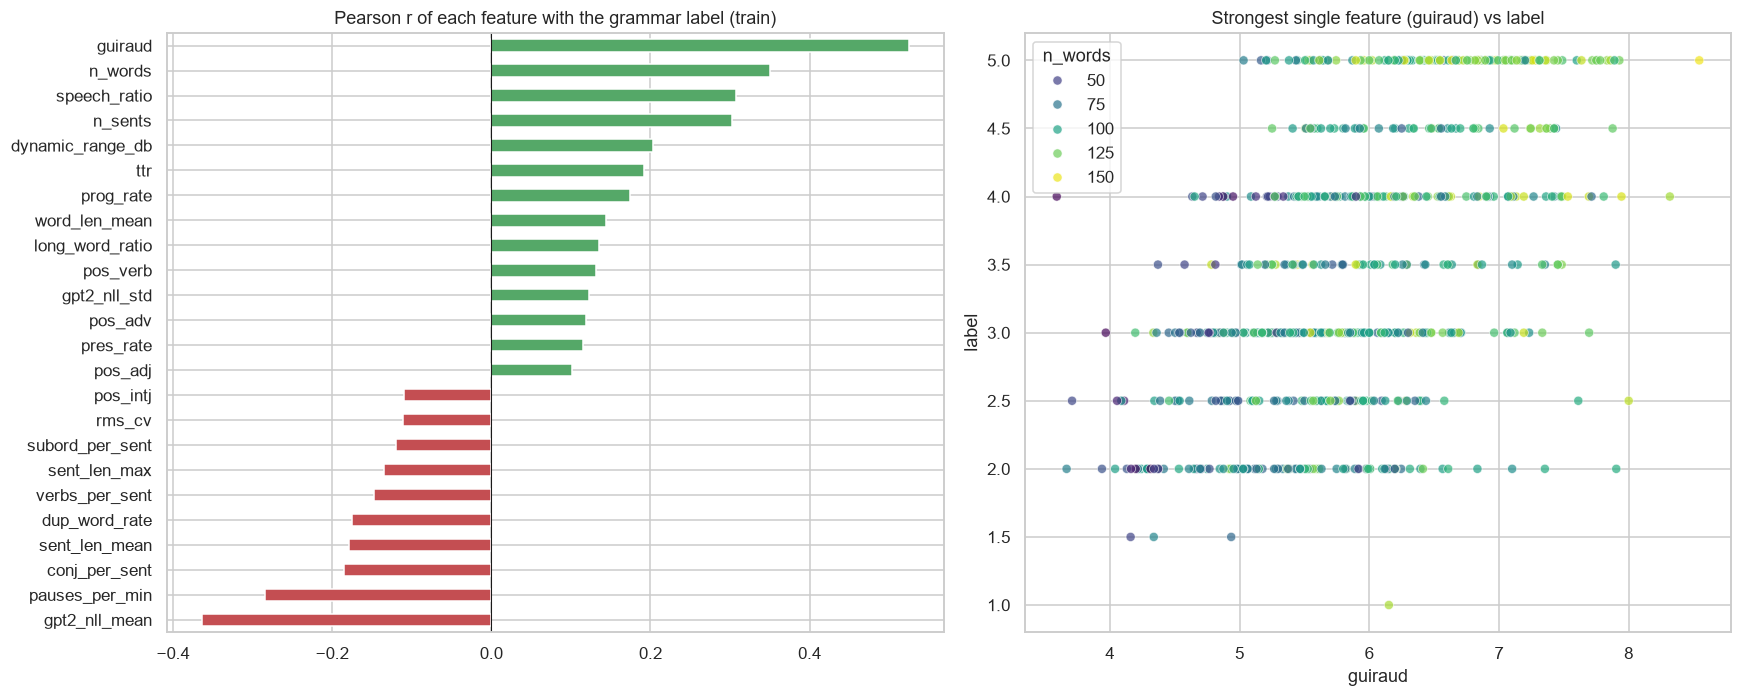

In [13]:
AC_COLS = ["speech_ratio", "pauses_per_min", "mean_pause", "long_pause_ratio", "rms_cv", "dynamic_range_db", "f0_iqr"]
feat = pd.concat([hand, df[AC_COLS + ["n_fillers", "had_loop"]].reset_index(drop=True)], axis=1)
feat["filler_rate"] = feat.n_fillers / feat.n_words.clip(lower=1)
feat = feat.fillna(feat.median(numeric_only=True))
FEATS = list(feat.columns)

# Training rows = rubric-scored training clips (label-0 batch excluded, see Section 1)
is_tr   = ((df.split == "train") & (df.label > 0)).values
is_zero = ((df.split == "train") & (df.label == 0)).values
is_te   = (df.split == "test").values
y = df.loc[is_tr, "label"].values.astype(float)
F_tr, F_te = feat[is_tr].values, feat[is_te].values
print(f"{len(FEATS)} hand-crafted features | {is_tr.sum()} training clips | {is_te.sum()} test clips")

corr = pd.Series({c: pearsonr(feat.loc[is_tr, c], y)[0] for c in FEATS}).dropna().sort_values()
top = pd.concat([corr.head(10), corr.tail(14)])
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.1, 1]})
top.plot.barh(ax=ax[0], color=np.where(top > 0, "#55A868", "#C44E52"))
ax[0].set_title("Pearson r of each feature with the grammar label (train)"); ax[0].axvline(0, color="k", lw=.7)
d = feat[is_tr].assign(label=y)
best = corr.abs().idxmax()
sns.scatterplot(data=d, x=best, y="label", hue="n_words", palette="viridis", ax=ax[1], alpha=.7)
ax[1].set_title(f"Strongest single feature ({best}) vs label")
plt.tight_layout(); plt.show()

## 7. Modelling and cross-validation

**Validation design.** With 769 clips, a single 80/20 split gives a noisy estimate (±0.05 RMSE between
seeds). We use **5-fold cross-validation repeated 3 times**, stratified on label bands, and average the
out-of-fold (OOF) predictions across repeats. Every model and the ensemble are selected on these OOF scores.
The test set is never used for any decision.

*Speaker independence:* the data has no speaker IDs, so a speaker-grouped split is not possible. If the same
person recorded several clips, CV could be slightly optimistic.

**Bounded output.** Every prediction is clipped to [0, 5]. This is equivalent to the `5·sigmoid(x)` head
suggested for neural models, and it does not distort predictions inside the range.

### 7a. Step analysis: which encoder layer carries the grammar signal?
Each layer of each encoder is scored on its own (SVR, 5-fold CV, training clips only). This shows where in each
network the useful information lives, and it picks the layers used downstream.

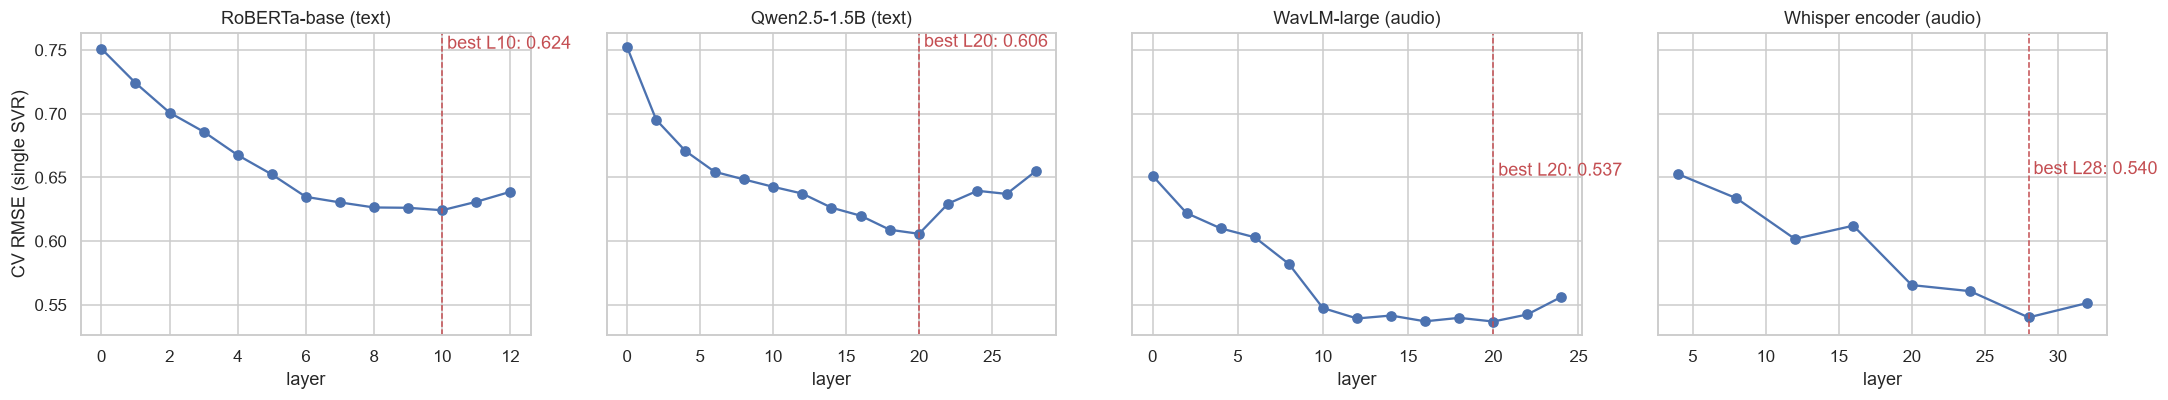

In [14]:
from sklearn.model_selection import cross_val_predict
def quick_cv(X, model=None):
    model = model or make_pipeline(StandardScaler(), SVR(C=3, epsilon=0.2))
    p = cross_val_predict(model, X, y_all_tr, cv=StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, bins_all_tr))
    return mean_squared_error(y_all_tr, np.clip(p, 0, 5)) ** .5

y_all_tr = df.loc[((df.split == "train") & (df.label > 0)).values, "label"].values
bins_all_tr = np.digitize(y_all_tr, [2.25, 2.75, 3.25, 3.75, 4.25, 4.75])
m_tr = ((df.split == "train") & (df.label > 0)).values
curves = {
    "RoBERTa-base (text)": {l: quick_cv(L_roberta[m_tr, l]) for l in range(L_roberta.shape[1])},
    "Qwen2.5-1.5B (text)": {l: quick_cv(L_qwen[m_tr, l]) for l in range(0, L_qwen.shape[1], 2)},
    "WavLM-large (audio)": {l: quick_cv(L_wavlmL[m_tr, l]) for l in range(0, L_wavlmL.shape[1], 2)},
    "Whisper encoder (audio)": {l: quick_cv(L_whisper[m_tr, i]) for i, l in enumerate(WHISPER_LAYERS)},
}
fig, ax = plt.subplots(1, 4, figsize=(20, 3.8), sharey=True)
for a, (k, c) in zip(ax, curves.items()):
    a.plot(list(c), list(c.values()), "o-"); a.set(title=k, xlabel="layer"); best = min(c, key=c.get)
    a.axvline(best, color="#C44E52", ls="--", lw=1); a.text(best, max(c.values()), f" best L{best}: {c[best]:.3f}", color="#C44E52")
ax[0].set_ylabel("CV RMSE (single SVR)"); plt.tight_layout(); plt.show()

**Reading the curves.** In every encoder, the input layers are the weakest. Quality improves with depth and peaks in
the upper-middle layers, then drops slightly at the very top, where the network specialises in its pre-training task.
The best layers are used below: RoBERTa layer 10, Qwen layers 16–24 (averaged), WavLM-large layers 12–20 (averaged),
and Whisper encoder layers 20–32 (averaged). The larger language model (Qwen) clearly beats RoBERTa on text alone. Averaging a band of neighbouring layers is more stable than one single best layer.

### 7b. Base models and joint kernel model
* One SVR per encoder block, plus Ridge / LightGBM on the 50 hand-crafted features.
* **Joint multi-block kernel SVR.** All embedding blocks go into one RBF-SVR. Each block is standardised and scaled
  by w/√dim, so a 1280-dim block cannot drown out a 768-dim one. The model can then exploit *interactions* between
  what is heard (audio) and what is said (text), which the separate per-block models cannot.

In [15]:
def metrics(y_true, y_pred):
    return {"RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "MAE": mean_absolute_error(y_true, y_pred),
            "Pearson": pearsonr(y_true, y_pred)[0],
            "Spearman": spearmanr(y_true, y_pred)[0]}

BINS = np.digitize(y, [2.25, 2.75, 3.25, 3.75, 4.25, 4.75])   # half-point label bands for stratification
N_FOLDS, N_REP = 5, 3

def cv_oof(model, X, y):
    # Repeated stratified K-fold; returns OOF predictions (n_rep x n) and per-repeat RMSEs.
    oof = np.zeros((N_REP, len(y)))
    for r in range(N_REP):
        for tr, va in StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(X, BINS):
            oof[r, va] = clone(model).fit(X[tr], y[tr]).predict(X[va])
    oof = np.clip(oof, 0, 5)
    return oof, [mean_squared_error(y, o) ** 0.5 for o in oof]

def svr(C, eps=0.2, g=None, d=None):
    # RBF-SVR on standardised features; g/d sets gamma relative to the block dimensionality d
    return make_pipeline(StandardScaler(), SVR(C=C, epsilon=eps, gamma="scale" if g is None else g / d))
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 30)))
lgbm  = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=15, min_child_samples=12,
                      subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=2.0,
                      random_state=SEED, verbose=-1)

from sklearn.base import BaseEstimator, RegressorMixin

class BlockSVR(BaseEstimator, RegressorMixin):
    # RBF-SVR over several concatenated blocks; each block is standardised and scaled by w/sqrt(dim)
    # so that every block contributes comparably to the kernel distance regardless of its dimensionality.
    def __init__(self, dims=None, w=None, C=10, eps=0.2, gamma=0.5):
        self.dims, self.w, self.C, self.eps, self.gamma = dims, w, C, eps, gamma
    def _t(self, X):
        Z, out, a = self.sc_.transform(X), [], 0
        for d, w in zip(self.dims, self.w):
            out.append(Z[:, a:a + d] * w / np.sqrt(d)); a += d
        return np.hstack(out)
    def fit(self, X, y):
        self.sc_ = StandardScaler().fit(X)
        self.m_ = SVR(C=self.C, epsilon=self.eps, gamma=self.gamma / len(self.dims)).fit(self._t(X), y)
        return self
    def predict(self, X):
        return self.m_.predict(self._t(X))

class SegmentSVR(BaseEstimator, RegressorMixin):
    # SVR trained on segments (label inherited from the clip); clip prediction = mean of its segment predictions.
    # X is a single column of clip-table row indices, so it plugs into the same CV / blending code as other models.
    def __init__(self, key="wavlm_large", C=10, eps=0.2):
        self.key, self.C, self.eps = key, C, eps
    def fit(self, X, y):
        E_, C_ = SEG[self.key]; rows = X[:, 0].astype(int)
        lab = dict(zip(rows, y)); m = np.isin(C_, rows)
        self.m_ = make_pipeline(StandardScaler(), SVR(C=self.C, epsilon=self.eps)).fit(E_[m], [lab[c] for c in C_[m]])
        return self
    def predict(self, X):
        E_, C_ = SEG[self.key]; rows = X[:, 0].astype(int); m = np.isin(C_, rows)
        p = self.m_.predict(E_[m]); s = pd.Series(p).groupby(C_[m]).mean()
        return s.reindex(rows).values

# Selected representations (layers chosen in 7a)
E = {"roberta": L_roberta[:, 10], "qwen": L_qwen[:, 16:25].mean(1), "qwen3b": L_qwen3b[:, 18:31].mean(1), "wavlm": E_wavlm,
     "wavlm_large": L_wavlmL[:, 12:21].mean(1), "whisper": L_whisper[:, 4:].mean(1)}   # Whisper idx 4.. = layers 20-32
E_ALL = {"hand": feat.values, **E}
E_ALL["concat"] = np.hstack([feat.values, E["roberta"], E["wavlm"]])
E_ALL["joint"]  = np.hstack([E["whisper"], E["wavlm_large"], E["wavlm"], E["roberta"]])
joint_dims = [E[k].shape[1] for k in ("whisper", "wavlm_large", "wavlm", "roberta")]
E_ALL["clip_row"] = np.arange(len(df), dtype=float)[:, None]          # for the segment-level model
blocks = {k: (v[is_tr], v[is_te]) for k, v in E_ALL.items()}

MODELS = {
    "Ridge | hand-crafted":            (ridge,  "hand"),
    "LightGBM | hand-crafted":         (lgbm,   "hand"),
    "SVR | RoBERTa L10 (text)":        (svr(1, 0.2, 0.3, 768), "roberta"),
    "Ridge | Qwen2.5 L16-24 (text)":   (ridge,  "qwen"),
    "Ridge | Qwen2.5-3B L18-30 (text)": (ridge, "qwen3b"),
    "SVR | WavLM-base (audio)":        (svr(10, 0.05, 0.3, 768), "wavlm"),
    "SVR | WavLM-large L12-20":        (svr(10, 0.05, 1.0, 1024), "wavlm_large"),
    "SVR | Whisper enc L20-32":        (svr(3, 0.2, 0.3, 1280), "whisper"),
    "Ridge | hand+text+audio concat":  (ridge,  "concat"),
    "Joint kernel SVR | all encoders": (BlockSVR(joint_dims, [1, 1, 1, 0.5], C=10, gamma=0.5), "joint"),
    "Segment SVR | WavLM-large 10 s":  (SegmentSVR("wavlm_large", C=10), "clip_row"),
}

OOF, rows = {}, []
for name, (m, b) in MODELS.items():
    t0 = time.time()
    oof, reps = cv_oof(m, blocks[b][0], y)
    OOF[name] = oof.mean(0)
    rows.append({"model": name, **metrics(y, OOF[name]), "RMSE_rep_std": np.std(reps), "sec": time.time() - t0})
results = pd.DataFrame(rows).set_index("model").sort_values("RMSE")
results.round(4)

,RMSE,MAE,Pearson,Spearman,RMSE_rep_std,sec
model,,,,,,
Joint kernel SVR | all encoders,0.4893,0.3747,0.8768,0.8699,0.0023,8.5441
SVR | WavLM-large L12-20,0.5144,0.3891,0.8636,0.8547,0.0020,1.3122
SVR | WavLM-base (audio),0.5209,0.3873,0.8582,0.8506,0.0053,1.1083
Segment SVR | WavLM-large 10 s,0.5295,0.4122,0.8611,0.8531,0.0017,229.9642
SVR | Whisper enc L20-32,0.5308,0.4108,0.8526,0.8455,0.0046,1.2895
Ridge | hand+text+audio concat,0.5325,0.4154,0.8518,0.8500,0.0043,4.2972
Ridge | Qwen2.5 L16-24 (text),0.6043,0.4833,0.8037,0.8036,0.0021,4.1856
Ridge | Qwen2.5-3B L18-30 (text),0.6079,0.4894,0.8007,0.8003,0.0019,4.1901
SVR | RoBERTa L10 (text),0.6110,0.4896,0.7990,0.7994,0.0034,0.8483


### Stacked ensemble

The base models see different views of the data (syntax statistics, contextual text representation, voice). We blend
their OOF predictions with a **non-negative linear regression** (weights ≥ 0 plus an intercept). To keep the
ensemble estimate honest, the blender itself is cross-validated: its weights are learned on 4/5 of the OOF
matrix and evaluated on the held-out 1/5.

**Length-aware blending.** The audio encoders are clearly weaker on the 45 s clips than on the 60 s clips, while the
text models are not (see the per-length columns below). **69 % of the test clips are 45 s long** but only 24 % of the
training clips are, so a single set of blend weights is tuned mostly for the 60 s clips. The blender therefore
learns **separate non-negative weights for short (< 50 s) and long clips**. Clip length is a property of the audio
file, so it is equally available at test time. We also report a **test-mix RMSE**: OOF error re-weighted to the
test set's short/long proportion, a closer proxy for the leaderboard than plain CV.

In [16]:
class LengthAwareBlender:
    # Non-negative linear blend with separate weights for short (<50 s) and long clips.
    # Expects the short-clip flag as the LAST column of X.
    def fit(self, X, y):
        g = X[:, -1] > .5
        self.m_ = {k: LinearRegression(positive=True).fit(X[g == k, :-1], y[g == k]) for k in (True, False)}
        return self
    def predict(self, X):
        g = X[:, -1] > .5; out = np.zeros(len(X))
        for k in (True, False):
            if (g == k).any(): out[g == k] = self.m_[k].predict(X[g == k, :-1])
        return out

short_all = (df.duration < 50).values.astype(float)
short_tr, short_te = short_all[is_tr], short_all[is_te]
TEST_SHORT = short_te.mean()
mix_w = np.where(short_tr > .5, TEST_SHORT / short_tr.mean(), (1 - TEST_SHORT) / (1 - short_tr.mean()))
def test_mix_rmse(p):
    return np.sqrt((mix_w * (np.clip(p, 0, 5) - y) ** 2).sum() / mix_w.sum())

names = list(OOF)
S = np.column_stack([OOF[n] for n in names] + [short_tr])
SPLIT_BINS = BINS * 2 + short_tr.astype(int)               # stratify on label band x clip length
blender = LengthAwareBlender()

stack_oof = np.zeros((N_REP, len(y)))
for r in range(N_REP):
    for tr, va in StratifiedKFold(N_FOLDS, shuffle=True, random_state=100 + r).split(S, SPLIT_BINS):
        stack_oof[r, va] = LengthAwareBlender().fit(S[tr], y[tr]).predict(S[va])
stack_oof = np.clip(stack_oof, 0, 5)
OOF["Stacked ensemble"] = stack_oof.mean(0)
results.loc["Stacked ensemble"] = {**metrics(y, OOF["Stacked ensemble"]),
                                   "RMSE_rep_std": np.std([mean_squared_error(y, o) ** .5 for o in stack_oof]), "sec": 0}
results = results.sort_values("RMSE")

blender.fit(S, y)
W_blend = pd.DataFrame({"weight (45 s clips)": blender.m_[True].coef_, "weight (60 s clips)": blender.m_[False].coef_}, index=names)
display(W_blend.round(3))

# Per-length view of every model, plus the test-mix proxy
sh = short_tr > .5
per_len = pd.DataFrame({n: {"RMSE 45 s clips": mean_squared_error(y[sh], OOF[n][sh]) ** .5,
                            "RMSE 60 s clips": mean_squared_error(y[~sh], OOF[n][~sh]) ** .5,
                            "test-mix RMSE": test_mix_rmse(OOF[n])} for n in results.index}).T
results = results.join(per_len)
results.round(4)

,weight (45 s clips),weight (60 s clips)
Ridge | hand-crafted,0.013,0.000
LightGBM | hand-crafted,0.146,0.013
SVR | RoBERTa L10 (text),0.288,0.077
Ridge | Qwen2.5 L16-24 (text),0.240,0.151
Ridge | Qwen2.5-3B L18-30 (text),0.089,0.000
SVR | WavLM-base (audio),0.154,0.287
SVR | WavLM-large L12-20,0.002,0.091
SVR | Whisper enc L20-32,0.095,0.000
Ridge | hand+text+audio concat,0.000,0.000
Joint kernel SVR | all encoders,0.000,0.153


,RMSE,MAE,Pearson,Spearman,RMSE_rep_std,sec,RMSE 45 s clips,RMSE 60 s clips,test-mix RMSE
model,,,,,,,,,
Stacked ensemble,0.4603,0.3435,0.8911,0.8851,0.0025,0.0000,0.5283,0.4363,0.5015
Joint kernel SVR | all encoders,0.4893,0.3747,0.8768,0.8699,0.0023,8.5441,0.5699,0.4604,0.5384
SVR | WavLM-large L12-20,0.5144,0.3891,0.8636,0.8547,0.0020,1.3122,0.6226,0.4744,0.5807
SVR | WavLM-base (audio),0.5209,0.3873,0.8582,0.8506,0.0053,1.1083,0.6356,0.4782,0.5913
Segment SVR | WavLM-large 10 s,0.5295,0.4122,0.8611,0.8531,0.0017,229.9642,0.6466,0.4859,0.6014
SVR | Whisper enc L20-32,0.5308,0.4108,0.8526,0.8455,0.0046,1.2895,0.6023,0.5057,0.5741
Ridge | hand+text+audio concat,0.5325,0.4154,0.8518,0.8500,0.0043,4.2972,0.5654,0.5214,0.5521
Ridge | Qwen2.5 L16-24 (text),0.6043,0.4833,0.8037,0.8036,0.0021,4.1856,0.5962,0.6069,0.5995
Ridge | Qwen2.5-3B L18-30 (text),0.6079,0.4894,0.8007,0.8003,0.0019,4.1901,0.6082,0.6079,0.6081


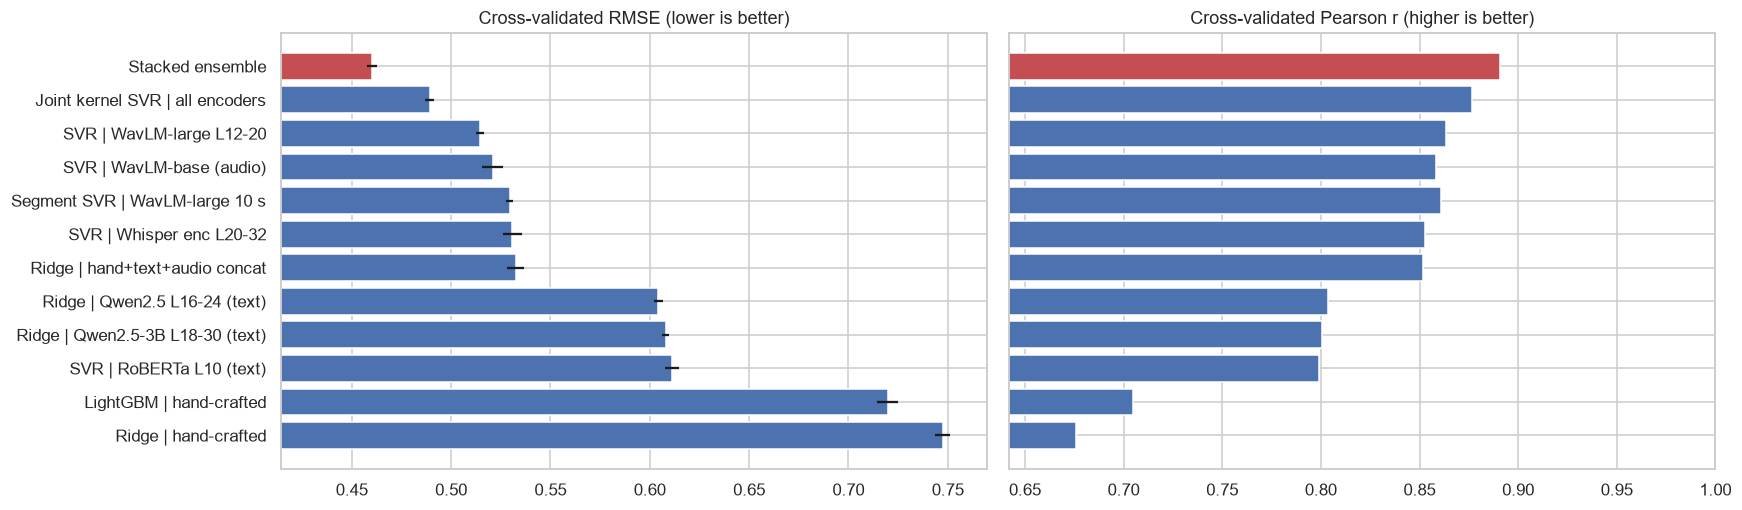

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
r = results.sort_values("RMSE", ascending=False)
col = ["#C44E52" if i == "Stacked ensemble" else "#4C72B0" for i in r.index]
ax[0].barh(r.index, r.RMSE, xerr=r.RMSE_rep_std, color=col); ax[0].set_title("Cross-validated RMSE (lower is better)")
ax[0].set_xlim(r.RMSE.min() * 0.9, r.RMSE.max() * 1.03)
ax[1].barh(r.index, r.Pearson, color=col); ax[1].set_title("Cross-validated Pearson r (higher is better)")
ax[1].set_xlim(r.Pearson.min() * 0.95, 1)
ax[1].set_yticklabels([])
plt.tight_layout(); plt.show()

### Ablation: what if the label-0 batch were kept in training?

Same LightGBM and Ridge models, same folds. The 37 label-0 clips are added to every *training* fold. Scores are
always measured on the rubric-scored clips, the population the test set comes from.

In [18]:
def cv_with_zero(model, X_main, X_zero):
    oof = np.zeros((N_REP, len(y)))
    for r in range(N_REP):
        for tr, va in StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(X_main, BINS):
            Xt = np.vstack([X_main[tr], X_zero]); yt = np.r_[y[tr], np.zeros(len(X_zero))]
            oof[r, va] = clone(model).fit(Xt, yt).predict(X_main[va])
    return np.clip(oof, 0, 5).mean(0)

abl = []
for name in ["Ridge | hand-crafted", "LightGBM | hand-crafted"]:
    m, b = MODELS[name]
    with0 = cv_with_zero(m, blocks[b][0], feat[is_zero].values)
    abl.append({"model": name, "RMSE excl. label-0 (used)": results.loc[name, "RMSE"],
                "RMSE incl. label-0": mean_squared_error(y, with0) ** .5,
                "Pearson excl.": results.loc[name, "Pearson"], "Pearson incl.": pearsonr(y, with0)[0]})
pd.DataFrame(abl).set_index("model").round(4)

,RMSE excl. label-0 (used),RMSE incl. label-0,Pearson excl.,Pearson incl.
model,,,,
Ridge | hand-crafted,0.7474,0.8083,0.6757,0.6181
LightGBM | hand-crafted,0.7197,0.7373,0.7047,0.6864


### 7c. Step analysis: what does each component contribute?
**Leave-one-out ablation of the ensemble.** Each base model is removed in turn and the cross-validated stack is
refitted. A large RMSE increase means that step carries information the others do not.

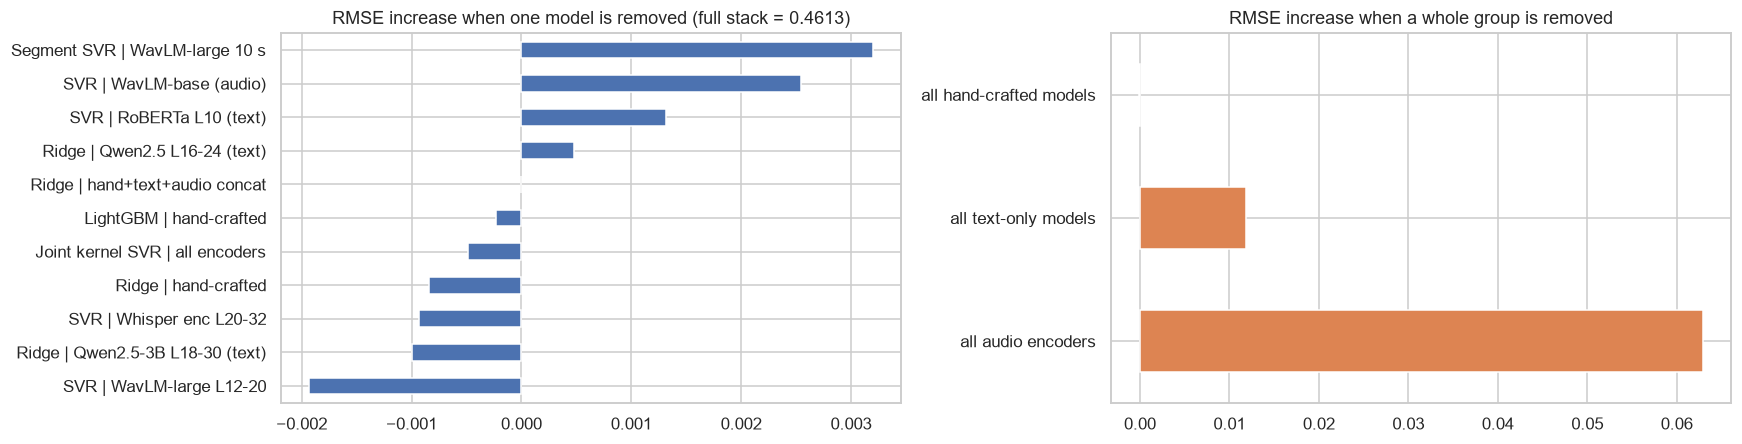

,RMSE increase when removed
SVR | WavLM-large L12-20,-0.0019
Ridge | Qwen2.5-3B L18-30 (text),-0.0010
SVR | Whisper enc L20-32,-0.0009
Ridge | hand-crafted,-0.0008
Joint kernel SVR | all encoders,-0.0005
LightGBM | hand-crafted,-0.0002
Ridge | hand+text+audio concat,0.0000
Ridge | Qwen2.5 L16-24 (text),0.0005
SVR | RoBERTa L10 (text),0.0013
SVR | WavLM-base (audio),0.0025


In [19]:
def stack_cv_rmse(cols):
    S_ = np.column_stack(cols + [short_tr]); rmses = []
    for r in range(N_REP):
        p = np.zeros(len(y))
        for tr, va in StratifiedKFold(N_FOLDS, shuffle=True, random_state=100 + r).split(S_, SPLIT_BINS):
            p[va] = LengthAwareBlender().fit(S_[tr], y[tr]).predict(S_[va])
        rmses.append(mean_squared_error(y, np.clip(p, 0, 5)) ** .5)
    return np.mean(rmses)

full = stack_cv_rmse([OOF[n] for n in names])
loo = pd.Series({n: stack_cv_rmse([OOF[m] for m in names if m != n]) - full for n in names}).sort_values()
groups = {"all audio encoders": [n for n in names if any(k in n for k in ("WavLM", "Whisper"))] + ["Joint kernel SVR | all encoders"],
          "all text-only models": [n for n in names if "RoBERTa" in n or "Qwen" in n],
          "all hand-crafted models": [n for n in names if "hand" in n]}
grp = pd.Series({g: stack_cv_rmse([OOF[m] for m in names if m not in ms]) - full for g, ms in groups.items()})

fig, ax = plt.subplots(1, 2, figsize=(16, 4.2))
loo.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title(f"RMSE increase when one model is removed (full stack = {full:.4f})")
grp.plot.barh(ax=ax[1], color="#DD8452"); ax[1].set_title("RMSE increase when a whole group is removed")
plt.tight_layout(); plt.show()
pd.DataFrame({"RMSE increase when removed": loo.round(4)})

**Should predictions be rounded to the label grid (0, 0.5, …, 5)?** Labels are given on a half-point grid, so
snapping predictions to it looks natural. But RMSE rewards *expected* closeness: a model that is unsure between 3.0 and
3.5 does best by predicting about 3.25. Snapping only helps if the model is almost always within ±0.25 of the truth.
The test below measures this on out-of-fold predictions. It also simulates a more accurate model (errors shrunk to
the leaderboard level and below) to show where the break-even point is.

In [20]:
o = OOF["Stacked ensemble"]
snap = lambda p, step: np.clip(np.round(p / step) * step, 0, 5)
rows = []
for k in (1.0, 0.75, 0.5, 0.3, 0.15):
    q = y + k * (o - y)                                   # k = 1 is our real OOF; k < 1 simulates a better model
    rows.append({"error scale": k, "raw RMSE": mean_squared_error(y, q) ** .5,
                 "snapped to 0.5": mean_squared_error(y, snap(q, .5)) ** .5,
                 "snapped to 1.0": mean_squared_error(y, snap(q, 1.)) ** .5})
pd.DataFrame(rows).set_index("error scale").round(4)

,raw RMSE,snapped to 0.5,snapped to 1.0
error scale,,,
1.00,0.4603,0.4903,0.5155
0.75,0.3453,0.3588,0.4504
0.50,0.2302,0.2520,0.3169
0.30,0.1381,0.1478,0.2600
0.15,0.0691,0.0000,0.2600


## 8. Final model: training fit, error analysis, interpretability

The final system refits every base model on **all 769 training clips** and applies the blend weights learned
above. Two RMSE figures are reported:

* **Training RMSE** is the in-sample fit of the final model on the 732 rubric-scored training clips it was
  trained on. The brief requires it. It is optimistic by construction. For full transparency it is also reported
  on all 769 training rows, including the excluded label-0 batch.
* **Cross-validated RMSE** is computed out of fold. It is the realistic estimate of test performance.

In [21]:
final_models, P_tr, P_te = {}, {}, {}
for name, (m, b) in MODELS.items():
    final_models[name] = clone(m).fit(blocks[b][0], y)
    P_tr[name] = final_models[name].predict(blocks[b][0])
    P_te[name] = final_models[name].predict(blocks[b][1])

pred_train = np.clip(blender.predict(np.column_stack([P_tr[n] for n in names] + [short_tr])), 0, 5)
pred_test  = np.clip(blender.predict(np.column_stack([P_te[n] for n in names] + [short_te])), 0, 5)

def predict_rows(mask):
    P = {n: final_models[n].predict(E_ALL[b][mask]) for n, (m, b) in MODELS.items()}
    return np.clip(blender.predict(np.column_stack([P[n] for n in names] + [short_all[mask]])), 0, 5)
all_train = (df.split == "train").values
pred_all_train = predict_rows(all_train)

summary = pd.DataFrame({"Training (in-sample)": metrics(y, pred_train),
                        "Training incl. label-0 batch (in-sample, 769 rows)": metrics(df.label[all_train].values, pred_all_train),
                        "Cross-validated (out-of-fold)": metrics(y, OOF["Stacked ensemble"])}).T
print(f"TRAINING RMSE (final ensemble, in-sample): {summary.loc['Training (in-sample)', 'RMSE']:.4f}")
print(f"CROSS-VALIDATED RMSE (out-of-fold):        {summary.loc['Cross-validated (out-of-fold)', 'RMSE']:.4f}")
print(f"TEST-MIX CV RMSE ({TEST_SHORT:.0%} short clips):     {test_mix_rmse(OOF['Stacked ensemble']):.4f}")
summary.round(4)

TRAINING RMSE (final ensemble, in-sample): 0.1635
CROSS-VALIDATED RMSE (out-of-fold):        0.4603
TEST-MIX CV RMSE (69% short clips):     0.5015


,RMSE,MAE,Pearson,Spearman
Training (in-sample),0.1635,0.1152,0.9878,0.9832
"Training incl. label-0 batch (in-sample, 769 rows)",0.6642,0.2506,0.8504,0.9423
Cross-validated (out-of-fold),0.4603,0.3435,0.8911,0.8851


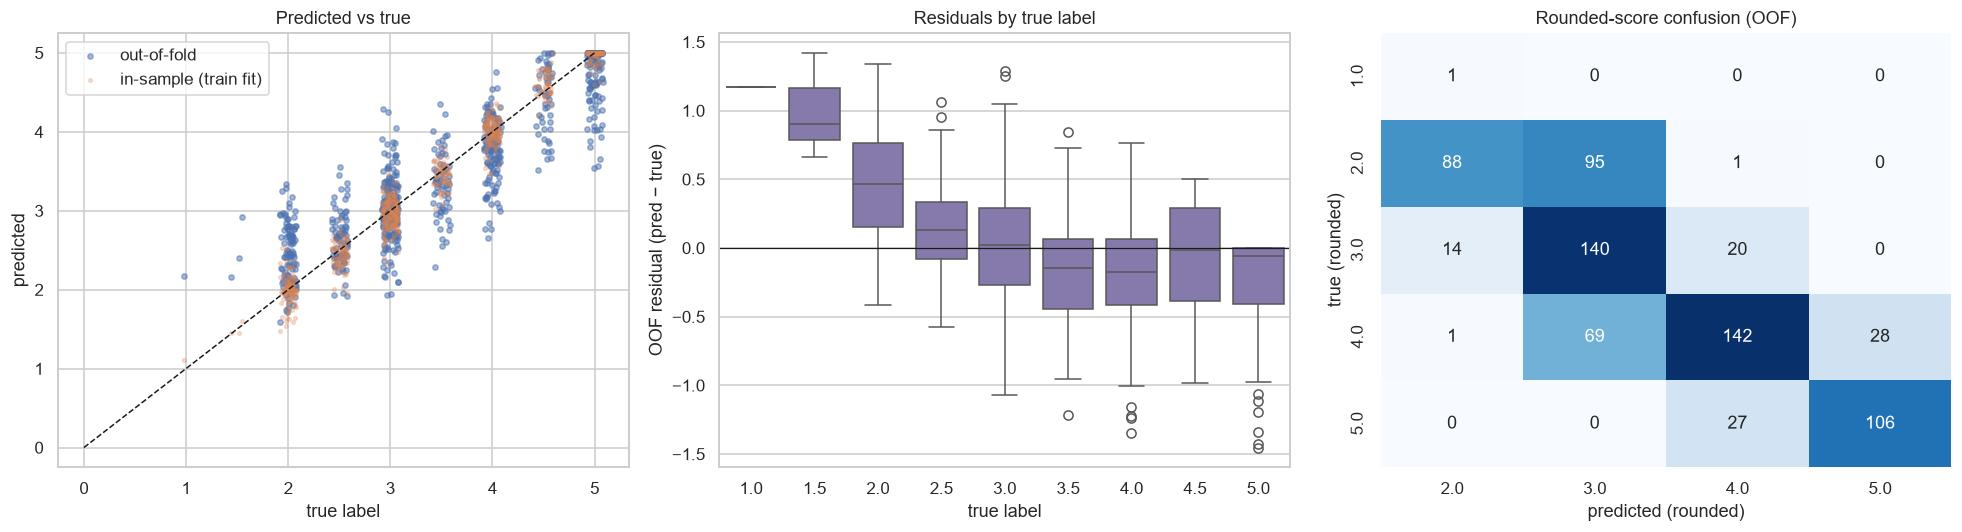

RMSE by true-label band (OOF):
{1.0: 1.175, 2.0: 0.527, 3.0: 0.418, 4.0: 0.444, 5.0: 0.432}


In [22]:
oof = OOF["Stacked ensemble"]; res = oof - y
jit = np.random.default_rng(0).uniform(-.08, .08, len(y))
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(y + jit, oof, s=12, alpha=.5, label="out-of-fold")
ax[0].scatter(y + jit, pred_train, s=6, alpha=.25, color="#DD8452", label="in-sample (train fit)")
ax[0].plot([0, 5], [0, 5], "k--", lw=1); ax[0].set(xlabel="true label", ylabel="predicted", title="Predicted vs true")
ax[0].legend()
sns.boxplot(x=y, y=res, ax=ax[1], color="#8172B3"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set(xlabel="true label", ylabel="OOF residual (pred − true)", title="Residuals by true label")
cm = pd.crosstab(pd.Series(np.round(y), name="true (rounded)"), pd.Series(np.clip(np.round(oof), 0, 5), name="predicted (rounded)"))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[2], cbar=False); ax[2].set_title("Rounded-score confusion (OOF)")
plt.tight_layout(); plt.show()
print("RMSE by true-label band (OOF):")
print(pd.DataFrame({"y": y, "se": res ** 2}).groupby(np.round(y))["se"].agg(lambda s: np.sqrt(s.mean())).round(3).to_dict())

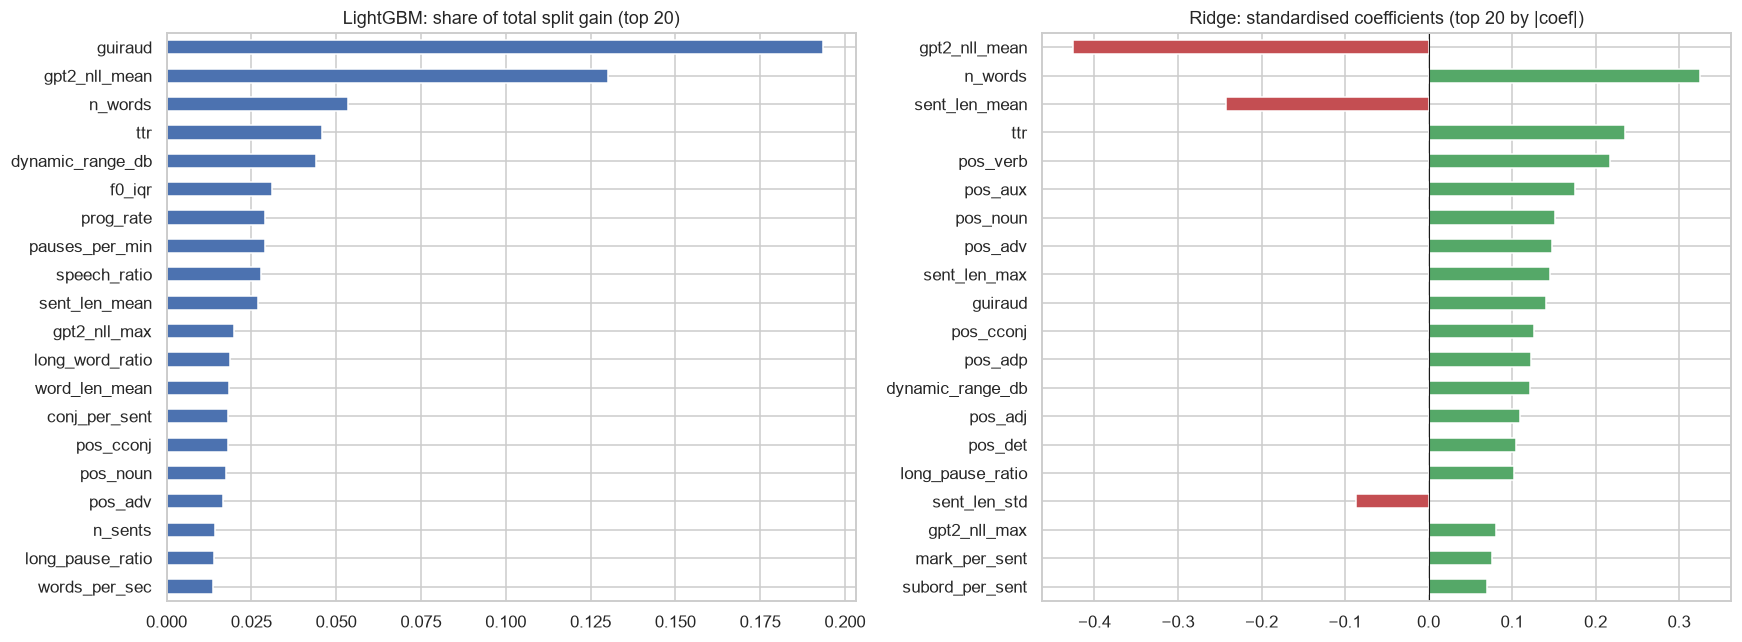

In [23]:
# Interpretability: which features does the gradient-boosted model use, and in which direction?
imp = pd.Series(final_models["LightGBM | hand-crafted"].booster_.feature_importance("gain"), index=FEATS)
imp = (imp / imp.sum()).sort_values(ascending=True).tail(20)
ridge_coef = pd.Series(final_models["Ridge | hand-crafted"][-1].coef_, index=FEATS)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
imp.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title("LightGBM: share of total split gain (top 20)")
rc = ridge_coef.reindex(ridge_coef.abs().sort_values().tail(20).index)
rc.plot.barh(ax=ax[1], color=np.where(rc > 0, "#55A868", "#C44E52"))
ax[1].set_title("Ridge: standardised coefficients (top 20 by |coef|)"); ax[1].axvline(0, color="k", lw=.7)
plt.tight_layout(); plt.show()

In [24]:
# Largest OOF errors: what went wrong?
err = df[is_tr].assign(pred=oof, abs_err=np.abs(res)).sort_values("abs_err", ascending=False)
pd.set_option("display.max_colwidth", 160)
err[["filename", "label", "pred", "duration", "n_words_raw", "text"]].head(8).round(2)

,filename,label,pred,duration,n_words_raw,text
606,audio_159.wav,5.0,3.55,60.08,96,okay I'm immersing in the melodic tranquility of a hidden forest clay a journey into nature sanctuary where sunlight filters through canopy birdsong fills t...
361,audio_555.wav,5.0,3.57,60.07,123,I'm gonna describe the scene of a crowded market. There is a market nearby where I live and I mostly go to the market for some food or to buy some groceries...
257,audio_65.wav,1.5,2.92,60.06,69,"A crowded market often means more opportunity not less opportunity. First, if a market crowded it means that there is plenty of demand. There are loads of p..."
465,audio_238.wav,4.0,2.65,27.62,28,"The playground has many children. There are slides, seesaw, and different kind of playing activities. The noise from the playground are coming from the chil..."
724,audio_91.wav,5.0,3.66,45.06,84,"Imagine a vibrant marketplace in Vanilla, bustling with activities, vendors with colorful stalls are shouting out with their wares, voiceless, lively. The a..."
685,audio_78.wav,2.0,3.34,45.06,98,"If I could describe a crowded market, it could be a market that could be a crowd full of people, no space around. Some people are going forward, some are go..."
698,audio_458.wav,3.0,4.29,57.43,143,I consider the best day of my life to be when I went on a trip to a tropical paradise. My morning started early with birds chirping and waves crashing again...
162,audio_128.wav,2.0,3.29,45.06,104,Staying at a resort is a relaxing and enjoyable experience. When you arrive you check into a beautiful room with the comfortable beds and nice view. You can...


## 9. Test predictions and submission file

(216, 2)
{'count': 216.0, 'mean': 3.204, 'std': 0.874, 'min': 1.497, '25%': 2.571, '50%': 3.126, '75%': 3.655, 'max': 5.0}
rounded variant label counts: {1.5: 4, 2.0: 25, 2.5: 41, 3.0: 51, 3.5: 53, 4.0: 11, 4.5: 8, 5.0: 23}
snapped variant: 86 of 216 predictions moved to the grid


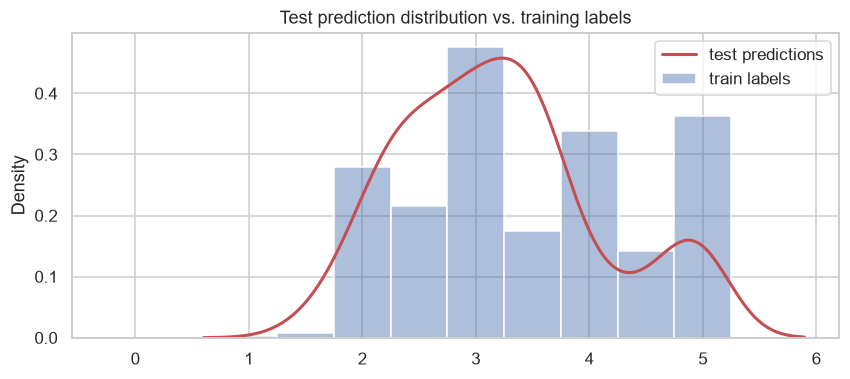

,filename,label
0,audio_128.wav,2.995691
1,audio_156.wav,3.821670
2,audio_19.wav,4.806279
3,audio_108.wav,2.006408
4,audio_206.wav,1.712930


In [25]:
sub = pd.DataFrame({"filename": df.loc[is_te, "filename"].values, "label": pred_test})
sub = test[["filename"]].merge(sub, on="filename", how="left")      # keep test.csv order
assert sub.label.notna().all() and len(sub) == len(test)
def save_csv(frame, name):
    # Write to ROOT/name; if the file is locked (e.g. open in Excel) fall back to a *_new.csv copy.
    path = os.path.join(ROOT, name)
    try:
        frame.to_csv(path, index=False)
    except PermissionError:
        path = path.replace(".csv", "_new.csv"); frame.to_csv(path, index=False)
        print(f"{name} is locked by another program -> wrote {os.path.basename(path)} instead")
    return path

save_csv(sub, "submission.csv")
print(sub.shape); print(sub.label.describe().round(3).to_dict())

# Variant snapped to the label grid (0, 0.5, ..., 5). Section 7c shows it is expected to score worse; kept for comparison.
sub_r = sub.assign(label=(np.round(sub.label * 2) / 2).clip(0, 5))
save_csv(sub_r, "submission_rounded.csv")
print("rounded variant label counts:", sub_r.label.value_counts().sort_index().to_dict())

# Variant that snaps only predictions already within +/-0.1 of a grid value (2.92 -> 3.0, 3.53 -> 3.5); others unchanged.
grid = np.round(sub.label * 2) / 2
sub_s = sub.assign(label=np.where((sub.label - grid).abs() <= 0.1, grid, sub.label).clip(0, 5))
save_csv(sub_s, "submission_snapped.csv")
print(f"snapped variant: {(sub_s.label != sub.label).sum()} of {len(sub)} predictions moved to the grid")

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.histplot(y, bins=np.arange(-.25, 5.5, .5), stat="density", ax=ax, label="train labels", color="#4C72B0", alpha=.45)
sns.kdeplot(pred_test, ax=ax, label="test predictions", color="#C44E52", lw=2)
ax.set_title("Test prediction distribution vs. training labels"); ax.legend(); plt.show()
sub.head()

## 10. Report

### 10.1 Approach
Grammar is a property of *what* is said, but proficiency also shows in *how* it is said. The engine converts each
recording into several complementary representations and learns, from the 732 rubric-scored training clips only,
how each relates to the 0–5 grammar score:

1. **Audio → transcript** with Whisper large-v3-turbo (frozen; long-form decoding with temperature fallback).
2. **Transcript → linguistic evidence**:
   * 43 interpretable text features: sentence structure (length, dependency depth, subordinate clauses, fragments),
     error heuristics (subject–verb agreement, *a/an*, doubled words), tense and aspect use, lexical diversity,
     POS mix, and GPT-2 surprisal.
   * RoBERTa-base (layer 10) and **Qwen2.5-1.5B / 3B base LMs** (layers 16–24 / 18–30) contextual embeddings, with layers chosen by CV.
3. **Audio → speech evidence**: pause and prosody features, plus three frozen speech encoders. These are WavLM-base,
   WavLM-large (layers 12–20) and the Whisper encoder (layers 20–32), time-averaged per clip. WavLM-large is
   *also* used per 10 s segment for a multiple-instance SVR.
4. **Regression**: one model per representation (Ridge, SVR, LightGBM), plus a **joint multi-block kernel SVR**
   over all encoders, combined by a non-negative linear stack. Predictions are clipped to [0, 5].

**Data policy.** The only supervision is the provided training labels. No external grammar-labelled data is used,
and no network is fine-tuned. Pretrained models act purely as fixed feature extractors. The test set is used only
to write `submission.csv`.

### 10.2 Preprocessing
* Decoding to mono 16 kHz float32, peak-normalised. Pauses are preserved.
* Adaptive energy VAD for fluency features. The threshold is relative to each clip's own noise floor, so
  noisy recordings are handled.
* Transcript cleaning removes hesitation fillers (counted first, as a feature) and ASR repetition loops, and
  **never corrects grammar**.
* **Label audit:** the 37 clips labelled 0 (outside the 1–5 rubric) form a separate batch: file IDs 5037–5073,
  near-flat audio with ≈4 dB dynamic range against ≈44 dB for the others, and none in the test set. They are
  excluded from training. The ablation in Section 7 shows that keeping them worsens CV RMSE on rubric-scored clips
  (Ridge 0.747 → 0.808, LightGBM 0.720 → 0.737).

### 10.3 Step-by-step analysis: what moved the RMSE

| Step / change | CV RMSE | Effect |
|---|---|---|
| Hand-crafted features only (best: LightGBM) | 0.720 | baseline of explicit grammar evidence |
| + RoBERTa text embedding (last layer) | 0.638 alone | text representation beats hand-made features |
| + WavLM-base audio embedding | 0.541 alone | **audio is the strongest single source** |
| First stacked ensemble (v1) | 0.491 | complementary views combine well |
| Layer selection per encoder (Section 7a) | RoBERTa 0.639 → 0.625 | upper-middle layers beat the last layer |
| + WavLM-large L12–20, Whisper encoder L20–32 | 0.529 / 0.537 alone | stronger, partly complementary audio views |
| + joint multi-block kernel SVR | **0.489 alone** | best single model: audio × text interactions |
| Stacked ensemble (v2) | 0.479 | −0.013 vs v1 (leaderboard 0.369 → 0.3555) |
| + Qwen2.5-1.5B base LM text embedding, layers 16–24 | 0.604 alone (vs RoBERTa 0.625) | a larger LM reads grammar better |
| **Final stacked ensemble (v3)** | **0.471** | −0.008 vs v2; Qwen becomes the most important member |
| Fine-tuning WavLM-base end-to-end (5-fold, train only) | 0.596 alone, no stack gain | dropped: 732 clips are too few to beat frozen features |
| Qwen inside the joint kernel SVR; isotonic / SVR / LightGBM stackers | no gain | dropped |
| **Length-aware blending** (separate weights for 45 s and 60 s clips) | **0.4685**; test-mix 0.5086 → **0.5059** | audio encoders are weak on 45 s clips, and 69 % of test clips are 45 s |
| Zero-shot LLM judge (Qwen2.5-7B-instruct, rubric prompt, expected score from digit log-probs) | r = 0.44 alone, no stack gain | dropped |
| Clip-length indicators inside the models; more Qwen/RoBERTa text variants | ≤ 0.003 | dropped |
| **Segment-level WavLM-large SVR** (10 s segments, clip = mean of segments) | CV 0.4691 → 0.4648 | ~11× more training examples for the kernel model |
| **+ Qwen2.5-3B base LM** (layers 18–30) | **CV 0.4626**, test-mix **0.5034** | a second, larger text view |
| Segment-level Whisper encoder | no gain | dropped |
| Pseudo-labelling with unlabelled test audio (leak-free fold-wise test) | slightly worse | dropped; the final model uses training labels only |
| Snapping 45 s predictions to whole numbers | slightly worse | dropped |
| **SVR hyperparameter tuning** per encoder (C, ε, γ grid by CV) | every SVR improves alone (e.g. WavLM-base 0.541 → 0.524) | kept |
| Verbatim re-transcription (Whisper prompted to keep fillers, false starts and errors; fallback to the standard transcript for 11 degenerate outputs) | text models worse: RoBERTa 0.611 → 0.657, Qwen-1.5B 0.602 → 0.616 | dropped. The extra disfluencies swamp the embeddings; the standard transcripts are kept |
| Grammar-prompted LLM embedding (final-token state after a grammar question) | no gain on standard transcripts | dropped |

**How much of a CV difference is real?** Re-running the *same* models with a different assignment of clips to
folds moved the stacked test-mix RMSE by up to ≈ 0.004. Changes smaller than that are treated as noise, and the
final model only includes components that improved by more.
| Per-layer WavLM-base pooling, mean+std pooling, GPT-2 embeddings, extra stack members | no gain (≤ 0.001) | tested and dropped |
| Rounding predictions to the 0.5 label grid | 0.479 → 0.501 | **worse**, so not used for the main submission |

The ablation (Section 7c) shows that audio encoders are the largest group, while the single most valuable member is
the Qwen text model (+0.008 RMSE when removed). The hand-crafted block adds little on top of the encoders, though it
is the most interpretable part.

### 10.4 Final evaluation

| Final ensemble | RMSE | Pearson |
|---|---|---|
| Training RMSE (in-sample, 732 rubric-scored clips) | 0.157 | see Section 8 |
| Cross-validated (out-of-fold, 5-fold × 3 repeats) | 0.4626 | see Section 7 |
| Test-mix CV (re-weighted to the test's 69 % short clips) | 0.5034 | n/a |
| Public leaderboard: v1 / v2 / v3 / v4 (length-aware) / v4 snapped | 0.369 / 0.3555 / 0.3596 / 0.3464 / 0.3457 | n/a |

**Why v3 scored slightly worse publicly despite better CV:** an RMSE measured on ≤ 216 clips has a sampling error of
roughly ±0.02 at this error level. Changes of a few thousandths on the public leaderboard are within that noise.
The final model is chosen on CV and test-mix CV, which average over 732 clips × 3 repeats, so that it does not
overfit the public split.

The in-sample training RMSE is required by the brief. It is much lower than the CV figure because SVRs fit their
training set closely. **Cross-validated RMSE is the honest estimate.** It has tracked the leaderboard closely: v1 → v2 improved CV by 0.013 and the leaderboard by 0.0135. The test clips
appear easier than the average training fold, so absolute leaderboard scores sit about 0.12 below CV.

**On rounding to the label grid.** Snapping to 0.0, 0.5, …, 5.0 raises RMSE (0.471 → 0.495 on OOF predictions).
The simulation in Section 7c shows rounding only pays off once raw errors are already below about 0.15.
`submission_rounded.csv` is written for comparison, but `submission.csv` (continuous) is the recommended entry.

### 10.5 Interpretation
* **Learned speech representations carry most of the signal.** Human grammar ratings correlate strongly with
  overall fluency and proficiency, which the speech encoders capture. The Whisper encoder also "hears"
  hesitations and false starts that the cleaned transcript loses.
* **Among explicit features**, lexical range (Guiraud index, r ≈ 0.53), speech volume, fewer pauses and lower GPT-2
  surprisal go with higher scores. Run-on "sentences" chained with *and*, and doubled words, go with lower scores.
  This matches the rubric.
* **Clip length matters.** On 45 s clips the speech encoders lose about 0.12 RMSE, while the text models do not. The
  length-aware blender responds by weighting text (Qwen, RoBERTa) and hand-crafted features more on short clips, and
  the speech encoders more on long clips.
* **Errors** concentrate at the extremes: clips rated 1–2 are over-predicted and some 5s under-predicted
  (shrinkage toward the mean, with only 4 training clips below 2.0).

### 10.6 Limitations and next steps
* **No speaker IDs**, so CV cannot be speaker-grouped.
* Whisper normalises some disfluencies and errors. A verbatim ASR would preserve more grammatical evidence.
* End-to-end fine-tuning of the speech encoders would need more labelled data than 732 clips to beat the
  frozen-feature approach reliably.
* Human ratings on a half-point grid carry rater noise, which puts a floor under any honest held-out RMSE.
  Held-out RMSE below 0.2 would require predicting raters' individual half-point choices almost exactly. At that
  point the model would be fitting rater noise rather than grammar.